# Lab 21 — LoRA / QLoRA Fine-tuning · **T4 / Free Colab Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Qwen2.5-3B** với LoRA/QLoRA trên một custom Vietnamese dataset, sau đó so sánh các rank khác nhau (`r=8`, `r=16`, `r=64`).

---

## ⚙️ Profile: `T4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Qwen2.5-3B-bnb-4bit` |
| Recommended GPU | T4 (16 GB) |
| Train batch / eval batch | 1 / 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Eval strategy | "no" |
| Max seq length cap | 1024 |
| Dataset samples | 200 |
| Estimated time | ~60 phút trên T4 |

> ⚠️ **T4-specific tweaks**: dùng model 3B (thay vì 7B), tắt eval-during-training, batch size = 1, manual eval fallback. Nếu bạn có GPU lớn hơn, dùng phiên bản BigGPU.

## Lab Roadmap (≈ 2 giờ)

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset preparation (Alpaca format, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Configure PEFT + load model 4-bit | model wrapped với LoRA |
| 3 | Train baseline `r=16` với SFTTrainer | adapter checkpoint |
| 4 | Rank experiment — train `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | Evaluate (perplexity + qualitative) | so sánh metrics |
| 6 | Save + viết report | deliverable |

## Deliverable

1. **3 LoRA adapter checkpoints** (`r=8, r=16, r=64`)
2. **Evaluation report** chứa training time, peak VRAM, eval perplexity, 5 qualitative before/after examples, training cost, kết luận về rank trade-off


## 0. Setup & Environment Check

In [1]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu May  7 16:07:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  Bạn có GPU lớn (>20GB VRAM). Nên dùng phiên bản BigGPU thay vì T4 này — sẽ nhanh hơn nhiều!")
elif 'T4' not in name:
    print(f"\n💡 Notebook này tối ưu cho T4 (16GB). GPU của bạn ({name}) có thể chạy được nhưng underutilized.")

✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.10.0+cu128


In [3]:
# Install Unsloth, TRL, datasets, evaluation libs
# trl >= 0.12 — accepts processing_class (matches transformers >= 4.46)
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas

In [4]:
# Optional: mount Google Drive to save checkpoints persistently
MOUNT_DRIVE = False  # ← đổi thành True nếu muốn save vào Drive

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_t4'
else:
    OUTPUT_DIR = '/content/lab21_lora_t4'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

✓ Output dir: /content/lab21_lora_t4


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Vietnamese instruction dataset từ HuggingFace.  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.


In [11]:
# ─── Load dataset và tự động fix lỗi thiếu dấu ngoặc mảng của JSON ───
import json
import re
from datasets import Dataset

def fix_and_load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    # Nếu file chứa các object mà chưa được bọc trong mảng [...]
    if content.startswith("{") and content.endswith("}"):
        # Thám dấu phẩy giữ các object liền kề (ví dụ: } {  -> }, {)
        content = re.sub(r'\}\s*\{', '},\n{', content)
        # Bọc toàn bộ thành một JSON array chuẩn
        content = f"[\n{content}\n]"

    return json.loads(content)

# Đọc file
train_data = fix_and_load_json("/content/train_dataset.json")
eval_data = fix_and_load_json("/content/eval_dataset.json")

# Chuyển đổi sang định dạng HuggingFace Dataset
raw_train = Dataset.from_list(train_data)
raw_eval = Dataset.from_list(eval_data)

print(f"✓ Loaded {len(raw_train)} train samples and {len(raw_eval)} eval samples")
print(f"✓ Columns: {raw_train.column_names}")
print("\n--- Sample 0 ---")
print(raw_train[0])

✓ Loaded 450 train samples and 50 eval samples
✓ Columns: ['input', 'instruction', 'output']

--- Sample 0 ---
{'input': "Q:A 26-year-old man comes to the physician because of discoloration of the toenails. He has a history of peptic ulcer disease treated with pantoprazole. The physician prescribes oral itraconazole for a fungal infection and temporarily discontinues pantoprazole. Which of the following best describes the reason for discontinuing pantoprazole therapy?? \n{'A': 'Increased toxicity of itraconazole due to cytochrome p450 induction', 'B': 'Decreased therapeutic effect of itraconazole due to cytochrome p450 inhibition', 'C': 'Decreased therapeutic effect of itraconazole due to decreased absorption', 'D': 'Decreased therapeutic effect of itraconazole due to cytochrome p450 induction', 'E': 'Increased toxicity of itraconazole due to decreased protein binding'},", 'instruction': 'Please answer with one of the option in the bracket', 'output': 'C: Decreased therapeutic effect o

In [ ]:
# ─── Option B: dùng custom data (uncomment + chỉnh) ───
# from datasets import Dataset
# my_data = [
#     {"instruction": "...", "input": "", "output": "..."},
#     # ... 100-500 examples
# ]
# raw = Dataset.from_list(my_data)
# print(f"✓ Custom dataset: {len(raw)} samples")

In [13]:
# Auto-detect column names
cols = raw_train.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

train_ds = raw_train.map(format_alpaca, remove_columns=raw_train.column_names)
eval_ds = raw_eval.map(format_alpaca, remove_columns=raw_eval.column_names)

# Gom chung lại thành 'ds' để cell 10 tính toán độ dài token
from datasets import concatenate_datasets
ds = concatenate_datasets([train_ds, eval_ds])

print("\n--- Formatted sample ---")
print(train_ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction', input='input', output='output'


Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]


--- Formatted sample ---
### Instruction:
Please answer with one of the option in the bracket

### Input:
Q:A 26-year-old man comes to the physician because of discoloration of the toenails. He has a history of peptic ulcer disease treated with pantoprazole. The physician prescribes oral itraconazole for a fungal infection and temporarily discontinues pantoprazole. Which of the following best describes the reason for discontinuing pantoprazole therapy?? 
{'A': 'Increased toxicity of itraconazole due to cytochrome p450 i


Token length distribution:
  min=145, max=952
  p50=286, p95=458, p99=582

✓ Chọn max_seq_length = 512 (cap = 1024)


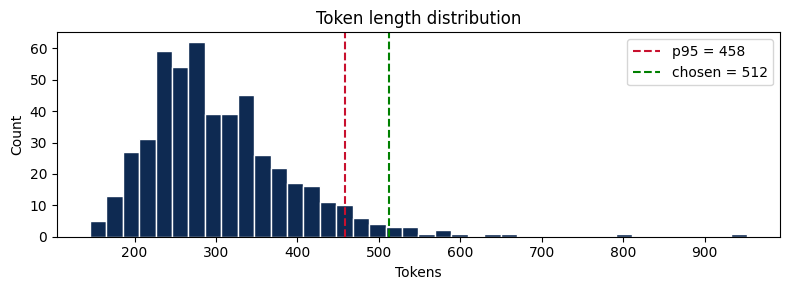

In [15]:
# Token length analysis → set max_seq_length = p95
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Qwen2.5-3B-bnb-4bit"
MAX_SEQ_CAP = 1024  # hard cap cho profile T4

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Round up to power of 2, capped at MAX_SEQ_CAP
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
# Sử dụng tập train và eval đã chia sẵn từ file upload (bỏ qua random split)
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 450  |  Eval: 50


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-3B** đã pre-quantize 4-bit (NF4). Unsloth tự động bật custom CUDA kernels.

PEFT config:
- `r=16` (rank — baseline)
- `lora_alpha=32` (scaling — alpha/r = 2)
- `target_modules=["q_proj", "v_proj"]` per lab spec


In [17]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha):
    """Wrap model với LoRA adapter."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],  # lab spec
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",  # -60% VRAM
        random_state=42,
    )

# Load base + wrap với r=16 baseline
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 36 layers with 36 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 3,686,400 (0.217% of 1,702,359,040)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, packing=True
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: "no"  # T4 không đủ VRAM cho mid-train eval


In [19]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Aggressive fix: alias tokenizer→processing_class for old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to="none",
    )
    base_kwargs[_EVAL_KEY] = "no"  # T4 không đủ VRAM cho mid-train eval
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — handles NotebookProgressCallback bug + OOM."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    # Remove buggy notebook callback that breaks evaluate-after-train
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    # Try standard evaluate first
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    # Manual eval loop — bulletproof
    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0


In [20]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/450 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/50 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


...

Step,Training Loss
5,1.818488
10,1.781551
15,1.731756
20,1.645947
25,1.561235
30,1.416043
35,1.376576
40,1.363308
45,1.330657
50,1.387739


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-114/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-171/tokenizer_config.json.



✓ r=16 done in 10.2 min, peak VRAM = 5.0 GB


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`Atten

✓ r=16 eval loss = 1.3563, perplexity = 3.88


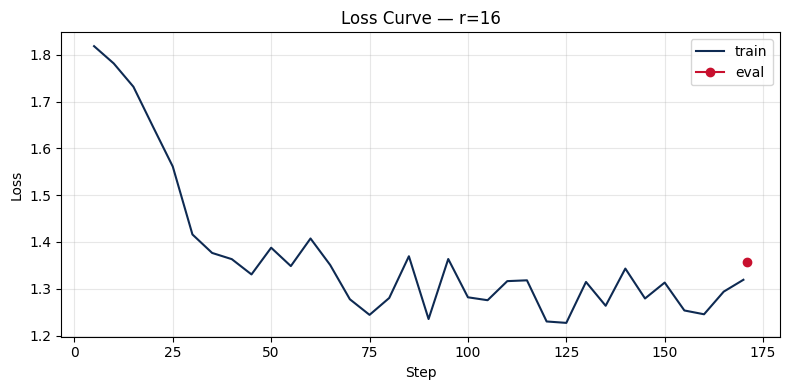


📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.


In [21]:
# Plot training loss để detect overfitting
import pandas as pd

def plot_losses(log_history, title="Training Loss"):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16")
print("\n📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.")

## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn


In [22]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save adapter BEFORE eval — eval may OOM but we want the checkpoint
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }

In [23]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/450 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 1,843,200 of 3,087,781,888 (0.06% trained)


Step,Training Loss
5,1.820015
10,1.799080
15,1.769395
20,1.692112
25,1.642791
30,1.512294
35,1.462474
40,1.411924
45,1.357154
50,1.411084


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-114/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-171/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/tokenizer_config.json.


✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [24]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/450 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,745,600 of 3,100,684,288 (0.48% trained)


Step,Training Loss
5,1.809044
10,1.722039
15,1.632309
20,1.494267
25,1.393542
30,1.324623
35,1.334866
40,1.321353
45,1.291235
50,1.350197


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-57/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-114/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-171/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/tokenizer_config.json.


✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [25]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8     16           1843200       10.197795      7.059070   1.365369         3.917169
   16     32           3686400       10.228888      4.983679   1.356342         3.881968
   64    128          14745600        9.982072      7.841594   1.349857         3.856875


## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned vs base model trên 5 prompts (chạy full 20 nếu thời gian cho phép).

In [26]:
TEST_PROMPTS = [
    """Q:A 16-year-old girl is brought to the emergency department unresponsive. A witness reports that she became anxious, lightheaded, and began sweating and trembling a few minutes before she lost consciousness. Her vitals are as follows: blood pressure 95/60 mm Hg, heart rate 110/min, respiratory rate 21/min, and temperature 35.5°C (95.5°F). She becomes responsive but is still somnolent. She complains of dizziness and weakness. A more detailed history reveals that she has drastically restricted her diet to lose weight for the past 18 hours, and has not eaten today. Her skin is pale, wet, and cold. The rest of the physical examination is unremarkable. Blood testing shows a plasma glucose level of 2.8 mmol/L (50.5 mg/dL). Which of the following statements is true??
{'A': 'There is an increase in the glycogen synthesis rate in this patient’s hepatocytes.', 'B': 'The patient’s symptoms are most likely the consequence of increased insulin secretion from the pancreatic islets.', 'C': 'Hypoglycemia in this patient is being compensated with an increased glycogenolysis rate.', 'D': 'Epinephrine-induced gluconeogenesis is the main process that allows for the compensation of a decreased glucose level.', 'E': 'The patient’s hypoglycemia inhibits glucagon release from pancreatic alpha cells.'},""",

    """Q:A 14-year-old girl presents to her pediatrician with complaints of repeated jerking of her neck for the past 2 years. Initially, her parents considered it a sign of discomfort in her neck, but later they noticed that the jerking was more frequent when she was under emotional stress or when she was fatigued. The patient says she can voluntarily control the jerking in some social situations, but when she is under stress, she feels the urge to jerk her neck and she feels better after that. The parents also report that during the past year, there have even been a few weeks when the frequency of the neck jerking had decreased drastically, only to increase again afterwards. On physical examination, she is a physically healthy female with normal vital signs. Her neurologic examination is normal. The pediatrician also notes that when he makes certain movements, the patient partially imitates these movements. The parents are very much concerned about her abnormal movements and insist on a complete diagnostic work-up. After a detailed history, physical examination, and laboratory investigations, the pediatrician confirms the diagnosis of Tourette syndrome. The presence of which of the following findings is most likely to confirm the pediatrician’s diagnosis??
{'A': 'History of repeated bouts of unprovoked obscene speech over the past year', 'B': 'Rigidity and bradykinesia', 'C': 'Low serum ceruloplasmin level', 'D': 'Decreased caudate volumes in magnetic resonance imaging (MRI) of the brain', 'E': 'Increased activity in frontal subcortical regions in positron-emission tomography (PET) study'},""",

    """Q:A 31-year-old African American woman with a history of Addison's disease presents with widespread, symmetric hypopigmented patches and macules overlying her face and shoulders. After a thorough interview and using a Wood’s lamp to exclude fungal etiology, vitiligo is suspected. Complete blood count shows leukocytes 6,300, Hct 48.3%, Hgb 16.2 g/dL, mean corpuscular volume (MCV) 90 fL, and platelets 292. Which of the statements below about this patient’s suspected disease is correct??
{'A': 'The course usually is slowly progressive with spontaneous repigmentation in 15% of patients.', 'B': 'The disease is relapsing and remitting with complete interval repigmentation.', 'C': 'Keloid formation is associated with regions of depigmentation.', 'D': 'Vitiligo is self-limited and will resolve in 8-14 weeks.', 'E': 'Topical corticosteroids are inappropriate for patients with limited disease.'},""",

    """Q:A 35-year-old man presents with large tense blisters on the flexor surfaces of the upper extremities and trunk. The histologic findings show subepidermal blisters with an eosinophil-rich infiltrate. What is the most likely underlying pathology??
{'A': 'Autoantibodies to desmoglein 1', 'B': 'Autoantibodies to desmoglein 3', 'C': 'Granular deposits of immunoglobulin A (IgA) in the dermal papilla', 'D': 'Linear band of immunoglobulin G (IgG) in the epidermal basement membrane', 'E': 'Linear band of IgA in the basement membrane'},""",

    """Q:A 67-year-old male with a past medical history of diabetes type II, obesity, and hyperlipidemia presents to the general medical clinic with bilateral hearing loss. He also reports new onset vertigo and ataxia. The symptoms started a day after undergoing an uncomplicated cholecystectomy. If a drug given prophylactically just prior to surgery has caused this patient’s symptoms, what is the mechanism of action of the drug??
{'A': 'Inhibition of the formation of the translation initiation complex', 'B': 'Inhibition of DNA-dependent RNA polymerase', 'C': 'Inhibition of cell wall synthesis', 'D': 'Inhibition of DNA gyrase', 'E': 'Formation of free radical toxic metabolites that damage DNA'},"""
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")


✓ 5 test prompts


In [27]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:300], "finetuned": ft_resp[:300],
    })
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 1: Q:A 16-year-old girl is brought to the emergency department unresponsive. A witn...


...

  BASE: A: The course usually is slowly progressive with spontaneous repigmentation in 15% of patients....
  FT  : C: Keloid formation is associated with regions of depigmentation.

### Explanation:
Vitiligo is a chronic condition characterized by the loss of melanocytes in the skin, leading to white patches. Whil...

━━━ Prompt 4: Q:A 35-year-old man presents with large tense blisters on the flexor surfaces of...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: B: Autoantibodies to desmoglein 3...
  FT  : D:Linear band of immunoglobulin G (IgG) in the epidermal basement membrane...

━━━ Prompt 5: Q:A 67-year-old male with a past medical history of diabetes type II, obesity, a...


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: C: Inhibition of cell wall synthesis...
  FT  : A: Inhibition of the formation of the translation initiation complex...


In [28]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

                                              prompt  \
0  Q:A 16-year-old girl is brought to the emergen...   
1  Q:A 14-year-old girl presents to her pediatric...   
2  Q:A 31-year-old African American woman with a ...   
3  Q:A 35-year-old man presents with large tense ...   
4  Q:A 67-year-old male with a past medical histo...   

                                                base  \
0  A: There is an increase in the glycogen synthe...   
1  A: History of repeated bouts of unprovoked obs...   
2  A: The course usually is slowly progressive wi...   
3                  B: Autoantibodies to desmoglein 3   
4               C: Inhibition of cell wall synthesis   

                                           finetuned  
0  E: The patient’s hypoglycemia inhibits glucago...  
1  D: Decreased caudate volumes in magnetic reson...  
2  C: Keloid formation is associated with regions...  
3  D:Linear band of immunoglobulin G (IgG) in the...  
4  A: Inhibition of the formation of the translat..

## 6. Save Adapters + Generate Report

In [29]:
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)

GPU_COST_USD_PER_HOUR = 0.35  # T4 default
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Tổng training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")


✓ Tổng training time: 30.4 phút
✓ Estimated cost: $0.18 (@ $0.35/hr)


In [31]:
# Optional: push adapter to HuggingFace Hub
PUSH_TO_HUB = True  # Đổi thành True
HUB_REPO_ID = "thang3092004/qwen2.5-3b-medqa-lora-r16" # Thay tên user của bạn vào đây

if PUSH_TO_HUB:
    from huggingface_hub import login
    login()
    ft_model.push_to_hub(HUB_REPO_ID)
    tok_for_eval.push_to_hub(HUB_REPO_ID)
    print(f"✓ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   4%|3         |  567kB / 14.8MB            

README.md: 0.00B [00:00, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpm5kgw99e/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpm5kgw99e/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

✓ Adapter pushed: https://huggingface.co/thang3092004/qwen2.5-3b-medqa-lora-r16


## ✅ Done — Submission Checklist

Trước khi nộp, verify đã có đủ trong `OUTPUT_DIR`:

- [ ] `r8/` — adapter checkpoint
- [ ] `r16/` — adapter checkpoint
- [ ] `r64/` — adapter checkpoint
- [ ] `rank_experiment_summary.csv` — bảng metrics
- [ ] `qualitative_comparison.csv` — 5+ before/after examples
- [ ] `REPORT.md` — đã điền phần "Kết luận"

**Nộp**: zip `OUTPUT_DIR` + push code lên GitHub repo cá nhân, gửi link cho instructor.